# 🧠 End-to-End Sentiment Analysis Pipeline
### Production-style NLP with Rich Feature Engineering, Model Comparison & Ablation Study

**Domain:** Customer reviews (food, movies, products, services)  
**Goal:** Binary or multi-class sentiment classification using traditional NLP + handcrafted features  
**Author:** Sentiment Analysis Pipeline v1.0

---
### Pipeline Overview
1. Imports & Setup
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering (TF-IDF + Handcrafted)
6. Feature Analysis
7. Modeling (Baseline → Advanced)
8. Evaluation
9. Ablation Study
10. Final Conclusion

In [2]:
!pip install textblob

---
## Section 1 — Imports & Setup

Install and import all required libraries. We use `sklearn` for modeling and pipelines, `nltk` for linguistic features, `textblob` for sentiment lexicons, and standard Python data science tools.

In [3]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# !pip install nltk textblob scikit-learn pandas numpy matplotlib seaborn
# !pip install emoji readability-lxml xgboost

# ── Standard library ─────────────────────────────────────────────────────────
import re
import string
import warnings
import unicodedata
from collections import Counter

# ── Data science ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── NLP ──────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords, opinion_lexicon
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from textblob import TextBlob

# ── Emoji ─────────────────────────────────────────────────────────────────────
try:
    import emoji
    EMOJI_AVAILABLE = True
except ImportError:
    EMOJI_AVAILABLE = False
    print("[INFO] emoji package not found — emoji count will use regex fallback")

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")

# ── NLTK downloads ────────────────────────────────────────────────────────────
for pkg in ["punkt", "stopwords", "averaged_perceptron_tagger",
             "wordnet", "opinion_lexicon", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("✅ All imports successful.")

[INFO] emoji package not found — emoji count will use regex fallback
✅ All imports successful.


---
## Section 2 — Data Loading

We load the **IMDB Movie Reviews dataset** (`IMDB_dataset.csv`) — 49,582 real movie reviews with binary sentiment labels.

**Raw CSV columns (Kaggle IMDB format):**
- `review` — raw HTML-containing review text (renamed → `text`)
- `sentiment` — `'positive'` or `'negative'` (renamed → `label`)

**What this cell does:**
1. Reads the CSV with proper encoding
2. Renames columns to the pipeline-standard `text` / `label`
3. Validates shape, label values, and null counts
4. Shows sample rows so you can confirm the data loaded correctly

> 📂 **Place `IMDB_dataset.csv` in the same folder as this notebook**, or update `CSV_PATH` below.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — update CSV_PATH if your file is in a different location
# ─────────────────────────────────────────────────────────────────────────────
CSV_PATH = "IMDB_dataset.csv"   # ← change path here if needed

# ── Load raw CSV ──────────────────────────────────────────────────────────────
# The Kaggle IMDB dataset uses UTF-8 encoding.
# Columns: 'review' (text) and 'sentiment' (positive/negative)
df_raw = pd.read_csv(CSV_PATH, encoding="utf-8")

print("Raw CSV loaded.")
print(f"  Shape      : {df_raw.shape}")
print(f"  Columns    : {df_raw.columns.tolist()}")
print(f"  Dtypes     :\n{df_raw.dtypes}")
print(f"\nFirst 2 raw rows:")
display(df_raw.head(2))

# ── Rename to pipeline-standard column names ──────────────────────────────────
# The IMDB CSV uses 'review' and 'sentiment' — we normalise to 'text' / 'label'
# so the rest of the notebook works without any further changes.
df_raw = df_raw.drop_duplicates(subset=['review']).reset_index(drop=True)
COLUMN_MAP = {
    "review":    "text",
    "sentiment": "label",
}
df = df_raw.rename(columns=COLUMN_MAP)[["text", "label"]].copy()

# ── Basic validation ──────────────────────────────────────────────────────────
assert "text"  in df.columns, "'text' column not found after renaming!"
assert "label" in df.columns, "'label' column not found after renaming!"

# Check label values
unique_labels = df["label"].unique().tolist()
assert set(unique_labels) == {"positive", "negative"}, \
    f"Unexpected label values: {unique_labels}"

# Drop rows with missing text or label (none expected in IMDB, but good practice)
before = len(df)
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 0].reset_index(drop=True)
after = len(df)
if before != after:
    print(f"[INFO] Dropped {before - after} rows with null/empty text or label.")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 50)
print(f"  Total rows : {len(df):,}")
print(f"  Columns    : {df.columns.tolist()}")
print(f"  Null values: {df.isnull().sum().to_dict()}")
print(f"\nLabel distribution:")
vc = df["label"].value_counts()
for lbl, cnt in vc.items():
    print(f"  {lbl:<12}: {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

print(f"\nSample rows:")
df[["text", "label"]].head(5)

Raw CSV loaded.
  Shape      : (50000, 2)
  Columns    : ['review', 'sentiment']
  Dtypes     :
review       object
sentiment    object
dtype: object

First 2 raw rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive



DATASET LOADED SUCCESSFULLY
  Total rows : 49,582
  Columns    : ['text', 'label']
  Null values: {'text': 0, 'label': 0}

Label distribution:
  positive    : 24,884  (50.2%)
  negative    : 24,698  (49.8%)

Sample rows:


,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
## Section 3 — Exploratory Data Analysis (EDA)

Before modeling, we explore the data to understand:
- Class balance
- Text length distributions
- Most frequent words per class

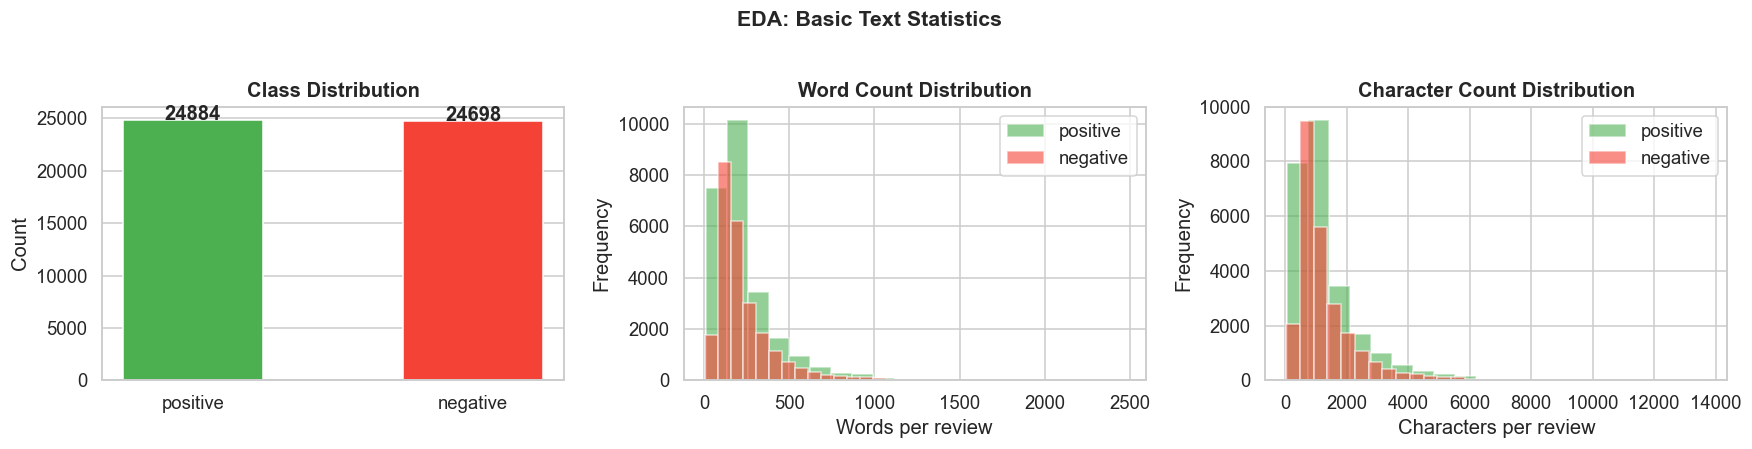

In [5]:
# ── 3.1 Class balance ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
label_counts = df["label"].value_counts()
axes[0].bar(label_counts.index, label_counts.values,
             color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Word count distribution
df["word_count_raw"] = df["text"].apply(lambda x: len(x.split()))
for label, color in zip(["positive", "negative"], ["#4CAF50", "#F44336"]):
    subset = df[df["label"] == label]["word_count_raw"]
    axes[1].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor="white")
axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words per review")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Char count distribution
df["char_count_raw"] = df["text"].apply(len)
for label, color in zip(["positive", "negative"], ["#4CAF50", "#F44336"]):
    subset = df[df["label"] == label]["char_count_raw"]
    axes[2].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor="white")
axes[2].set_title("Character Count Distribution", fontweight="bold")
axes[2].set_xlabel("Characters per review")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.suptitle("EDA: Basic Text Statistics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

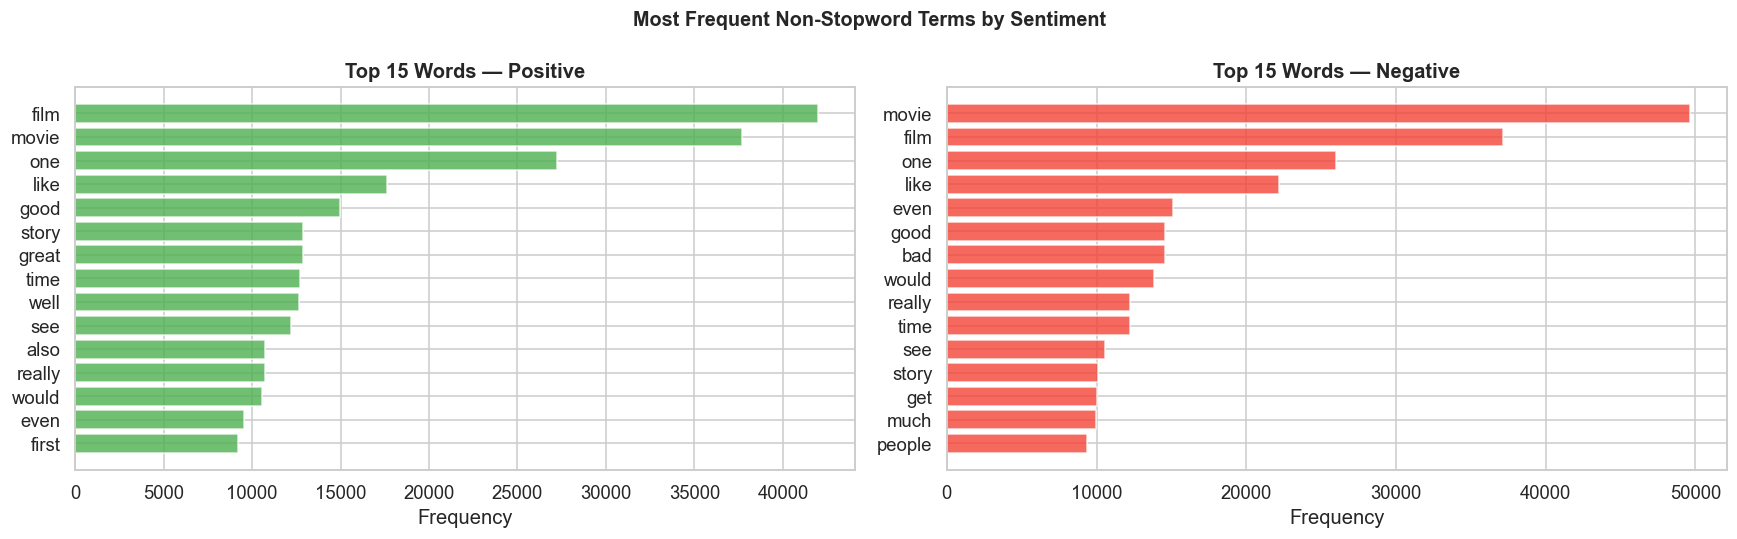

In [6]:
# ── 3.2 Top words per class ────────────────────────────────────────────────────
from collections import Counter

STOP = set(stopwords.words("english"))

def top_words(texts, n=15):
    words = []
    for t in texts:
        tokens = re.findall(r"\b[a-z]{3,}\b", t.lower())
        words.extend([w for w in tokens if w not in STOP])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, color in zip(axes, ["positive", "negative"], ["#4CAF50", "#F44336"]):
    subset = df[df["label"] == label]["text"]
    top = top_words(subset)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"Top 15 Words — {label.capitalize()}", fontweight="bold")
    ax.set_xlabel("Frequency")

plt.suptitle("Most Frequent Non-Stopword Terms by Sentiment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Clean up temp columns
df.drop(columns=["word_count_raw", "char_count_raw"], inplace=True)

---
## Section 4 — Data Cleaning & Preprocessing

We apply a two-track cleaning strategy:
- **`text_cleaned`** — fully normalized text for TF-IDF (lowercased, HTML stripped, no punctuation, lemmatized)
- **`text_raw`** — lightly cleaned text for handcrafted features (HTML tags removed, but case, punctuation, and emoji are preserved — they carry sentiment signal)

> ⚠️ **IMDB-specific:** The raw reviews contain `<br />` HTML line-break tags which we strip in both tracks. The `text_raw` track still keeps uppercase letters, `!`, `?`, and emojis intact for feature engineering.

In [7]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

# Negation cue words — used later in feature engineering
NEGATION_WORDS = {
    "not", "no", "never", "nothing", "neither", "nobody",
    "nowhere", "nor", "cannot", "can't", "won't", "isn't",
    "wasn't", "don't", "doesn't", "didn't", "hardly", "barely",
    "scarcely", "without"
}


def strip_html(text: str) -> str:
    """Remove HTML tags (e.g. <br />) and decode HTML entities."""
    text = re.sub(r"<[^>]+>", " ", text)     # strip all HTML tags
    text = re.sub(r"&amp;",  "&", text)
    text = re.sub(r"&lt;",   "<", text)
    text = re.sub(r"&gt;",   ">", text)
    text = re.sub(r"&quot;", '"', text)
    text = re.sub(r"&#39;",  "'", text)
    text = re.sub(r"\s+",    " ", text).strip()
    return text


def clean_text_for_tfidf(text: str) -> str:
    """
    Full cleaning for TF-IDF:
      - Strip HTML, lowercase, remove URLs
      - Remove non-alpha characters
      - Lemmatize tokens, remove stopwords (but KEEP negation words)
    """
    text = strip_html(text)                              # IMDB-specific: remove <br />
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # URLs
    text = re.sub(r"[^a-z\s']", " ", text)              # keep letters + apostrophe
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in STOP_WORDS or t in NEGATION_WORDS
    ]
    return " ".join(tokens)


def clean_text_for_features(text: str) -> str:
    """
    Light cleaning for handcrafted features:
      - Strip HTML only (preserve case, punctuation, emoji — they carry signal)
    """
    return strip_html(text)


# Apply cleaning
print("Applying two-track text cleaning...")
df["text_raw"]     = df["text"].apply(clean_text_for_features)  # HTML stripped, style preserved
df["text_cleaned"] = df["text"].apply(clean_text_for_tfidf)     # Fully normalized for TF-IDF

# Encode labels
label_map = {"negative": 0, "positive": 1}
df["label_enc"] = df["label"].map(label_map)

print("Cleaning complete.")
print(f"\nOriginal  : {df['text'].iloc[0][:120]}...")
print(f"text_raw  : {df['text_raw'].iloc[0][:120]}...")
print(f"text_clean: {df['text_cleaned'].iloc[0][:120]}...")
print(f"\nNull values: {df[['text_raw','text_cleaned']].isnull().sum().to_dict()}")
print(f"Label encoding: {label_map}")

Applying two-track text cleaning...
Cleaning complete.

Original  : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this...
text_raw  : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this...
text_clean: one reviewer mentioned watching oz episode 'll hooked right exactly happened first thing struck oz brutality unflinching...

Null values: {'text_raw': 0, 'text_cleaned': 0}
Label encoding: {'negative': 0, 'positive': 1}


---
## Section 5 — Feature Engineering

We engineer two feature groups:

### A. Text-Based Features
- Word-level TF-IDF (unigrams + bigrams)
- Character n-gram TF-IDF (captures morphology and misspellings)

### B. Handcrafted Features
A rich set of 20+ features capturing style, structure, sentiment, and linguistics.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# HANDCRAFTED FEATURE ENGINEERING
# Each function takes a raw (uncleaned) text string and returns a scalar.
# ─────────────────────────────────────────────────────────────────────────────

# ── Sentiment lexicons (NLTK Opinion Lexicon) ─────────────────────────────────
POS_WORDS = set(opinion_lexicon.positive())
NEG_WORDS = set(opinion_lexicon.negative())

# ── Emoji regex fallback ──────────────────────────────────────────────────────
EMOJI_PATTERN = re.compile(
    "["
    u"\U0001F600-\U0001F64F"   # emoticons
    u"\U0001F300-\U0001F5FF"   # symbols & pictographs
    u"\U0001F680-\U0001F6FF"   # transport & map
    u"\U0001F1E0-\U0001F1FF"   # flags
    u"\U00002500-\U00002BEF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE
)


# ─── Group 1: Length features ─────────────────────────────────────────────────

def feat_word_count(text):
    """Total number of whitespace-separated tokens."""
    return len(text.split())

def feat_char_count(text):
    """Total character count (including spaces)."""
    return len(text)

def feat_sentence_count(text):
    """Number of sentences detected by NLTK."""
    sents = sent_tokenize(text)
    return len(sents)

def feat_avg_sentence_length(text):
    """Average number of words per sentence."""
    sents = sent_tokenize(text)
    if not sents:
        return 0
    return np.mean([len(s.split()) for s in sents])

def feat_avg_word_length(text):
    """Average number of characters per word."""
    words = text.split()
    if not words:
        return 0
    return np.mean([len(w) for w in words])


# ─── Group 2: Punctuation features ───────────────────────────────────────────

def feat_exclamation_count(text):
    """Count of exclamation marks."""
    return text.count("!")

def feat_question_count(text):
    """Count of question marks."""
    return text.count("?")

def feat_punctuation_density(text):
    """Ratio of punctuation characters to total characters."""
    if len(text) == 0:
        return 0
    n_punct = sum(1 for c in text if c in string.punctuation)
    return n_punct / len(text)

def feat_uppercase_ratio(text):
    """Ratio of uppercase letters to all alpha characters."""
    alpha = [c for c in text if c.isalpha()]
    if not alpha:
        return 0
    return sum(1 for c in alpha if c.isupper()) / len(alpha)

def feat_repeated_chars(text):
    """Count of consecutive repeated characters (e.g. 'sooooo' → 3 extra)."""
    return len(re.findall(r"(.)\1{2,}", text))

def feat_repeated_words(text):
    """Count of consecutive duplicate words (e.g. 'very very good')."""
    words = text.lower().split()
    return sum(1 for i in range(1, len(words)) if words[i] == words[i-1])


# ─── Group 3: Lexical / linguistic features ───────────────────────────────────

def feat_lexical_diversity(text):
    """Type-Token Ratio: unique words / total words. Measures vocabulary richness."""
    words = text.lower().split()
    if not words:
        return 0
    return len(set(words)) / len(words)

def feat_stopword_ratio(text):
    """Fraction of tokens that are stopwords."""
    tokens = word_tokenize(text.lower())
    if not tokens:
        return 0
    return sum(1 for t in tokens if t in STOP_WORDS) / len(tokens)

def feat_negation_count(text):
    """Count of negation cue words in the text."""
    tokens = set(word_tokenize(text.lower()))
    return len(tokens & NEGATION_WORDS)

def feat_emoji_count(text):
    """Count of emoji characters."""
    if EMOJI_AVAILABLE:
        return emoji.emoji_count(text)
    return len(EMOJI_PATTERN.findall(text))


# ─── Group 4: Sentiment lexicon features ─────────────────────────────────────

def feat_pos_word_ratio(text):
    """Ratio of positive opinion lexicon words to total tokens."""
    tokens = word_tokenize(text.lower())
    if not tokens:
        return 0
    return sum(1 for t in tokens if t in POS_WORDS) / len(tokens)

def feat_neg_word_ratio(text):
    """Ratio of negative opinion lexicon words to total tokens."""
    tokens = word_tokenize(text.lower())
    if not tokens:
        return 0
    return sum(1 for t in tokens if t in NEG_WORDS) / len(tokens)

def feat_sentiment_net(text):
    """Net sentiment = positive ratio - negative ratio."""
    return feat_pos_word_ratio(text) - feat_neg_word_ratio(text)

def feat_textblob_polarity(text):
    """TextBlob polarity score in [-1, 1]."""
    return TextBlob(text).sentiment.polarity

def feat_textblob_subjectivity(text):
    """TextBlob subjectivity score in [0, 1]. 1 = highly subjective."""
    return TextBlob(text).sentiment.subjectivity


# ─── Group 5: Readability & POS ──────────────────────────────────────────────

def feat_flesch_reading_ease(text):
    """
    Flesch Reading Ease score (simplified inline calculation).
    Higher = easier to read. Range roughly 0–100.
    """
    sentences = sent_tokenize(text)
    words = text.split()
    if not sentences or not words:
        return 0
    syllables = sum(_count_syllables(w) for w in words)
    n_sent = len(sentences)
    n_word = len(words)
    return 206.835 - 1.015 * (n_word / n_sent) - 84.6 * (syllables / n_word)

def _count_syllables(word):
    """Approximate syllable counter using vowel groups."""
    word = word.lower().strip(string.punctuation)
    vowels = "aeiou"
    count = 0
    prev_vowel = False
    for ch in word:
        is_v = ch in vowels
        if is_v and not prev_vowel:
            count += 1
        prev_vowel = is_v
    if word.endswith("e") and count > 1:
        count -= 1
    return max(1, count)

def feat_noun_ratio(text):
    """Fraction of tokens that are nouns (NN, NNS, NNP, NNPS)."""
    tokens = word_tokenize(text)
    if not tokens:
        return 0
    tags = pos_tag(tokens)
    n_nouns = sum(1 for _, tag in tags if tag.startswith("NN"))
    return n_nouns / len(tokens)

def feat_adj_ratio(text):
    """Fraction of tokens that are adjectives (JJ, JJR, JJS)."""
    tokens = word_tokenize(text)
    if not tokens:
        return 0
    tags = pos_tag(tokens)
    n_adj = sum(1 for _, tag in tags if tag.startswith("JJ"))
    return n_adj / len(tokens)

def feat_adv_ratio(text):
    """Fraction of tokens that are adverbs (RB, RBR, RBS)."""
    tokens = word_tokenize(text)
    if not tokens:
        return 0
    tags = pos_tag(tokens)
    n_adv = sum(1 for _, tag in tags if tag.startswith("RB"))
    return n_adv / len(tokens)


print("✅ Feature functions defined.")
print(f"Total handcrafted features: 22")

✅ Feature functions defined.
Total handcrafted features: 22


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# APPLY ALL HANDCRAFTED FEATURES TO DATAFRAME
# Organized by feature group for the ablation study later.
# ─────────────────────────────────────────────────────────────────────────────

# Map: feature_name → (function, group)
FEATURE_GROUPS = {
    # Group A: Length
    "f_word_count":          (feat_word_count,          "length"),
    "f_char_count":          (feat_char_count,           "length"),
    "f_sentence_count":      (feat_sentence_count,       "length"),
    "f_avg_sent_len":        (feat_avg_sentence_length,  "length"),
    "f_avg_word_len":        (feat_avg_word_length,      "length"),
    # Group B: Punctuation
    "f_exclamation":         (feat_exclamation_count,    "punctuation"),
    "f_question":            (feat_question_count,       "punctuation"),
    "f_punct_density":       (feat_punctuation_density,  "punctuation"),
    "f_uppercase_ratio":     (feat_uppercase_ratio,      "punctuation"),
    "f_repeated_chars":      (feat_repeated_chars,       "punctuation"),
    "f_repeated_words":      (feat_repeated_words,       "punctuation"),
    # Group C: Lexical
    "f_lexical_diversity":   (feat_lexical_diversity,    "lexical"),
    "f_stopword_ratio":      (feat_stopword_ratio,       "lexical"),
    "f_negation_count":      (feat_negation_count,       "lexical"),
    "f_emoji_count":         (feat_emoji_count,          "lexical"),
    # Group D: Sentiment
    "f_pos_word_ratio":      (feat_pos_word_ratio,       "sentiment"),
    "f_neg_word_ratio":      (feat_neg_word_ratio,       "sentiment"),
    "f_sentiment_net":       (feat_sentiment_net,        "sentiment"),
    "f_tb_polarity":         (feat_textblob_polarity,    "sentiment"),
    "f_tb_subjectivity":     (feat_textblob_subjectivity,"sentiment"),
    # Group E: Readability / POS
    "f_flesch":              (feat_flesch_reading_ease,  "readability"),
    "f_noun_ratio":          (feat_noun_ratio,           "readability"),
    "f_adj_ratio":           (feat_adj_ratio,            "readability"),
    "f_adv_ratio":           (feat_adv_ratio,            "readability"),
}

HANDCRAFTED_COLS = list(FEATURE_GROUPS.keys())
GROUP_MAP = {name: grp for name, (_, grp) in FEATURE_GROUPS.items()}

print("Computing handcrafted features (POS tagging may take ~1–2 min)...")
for col, (fn, grp) in FEATURE_GROUPS.items():
    df[col] = df["text_raw"].apply(fn)

print(f"✅ Done. Added {len(HANDCRAFTED_COLS)} handcrafted feature columns.")
df[HANDCRAFTED_COLS].describe().round(3)

Computing handcrafted features (POS tagging may take ~1–2 min)...
✅ Done. Added 24 handcrafted feature columns.


,f_word_count,f_char_count,f_sentence_count,f_avg_sent_len,f_avg_word_len,f_exclamation,f_question,f_punct_density,f_uppercase_ratio,f_repeated_chars,...,f_emoji_count,f_pos_word_ratio,f_neg_word_ratio,f_sentiment_net,f_tb_polarity,f_tb_subjectivity,f_flesch,f_noun_ratio,f_adj_ratio,f_adv_ratio
count,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,...,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000,49582.000
mean,229.057,1288.022,12.336,20.375,4.601,0.978,0.647,0.032,0.036,0.671,...,0.000,0.040,0.036,0.004,0.103,0.531,67.200,0.225,0.078,0.061
std,169.786,973.459,8.884,14.560,0.339,2.915,1.526,0.011,0.020,1.634,...,0.046,0.021,0.020,0.033,0.164,0.092,18.471,0.045,0.024,0.023
min,4.000,32.000,1.000,1.050,1.240,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,-0.222,-1.000,0.000,-502.371,0.023,0.000,0.000
25%,125.000,690.000,7.000,14.500,4.379,0.000,0.000,0.025,0.024,0.000,...,0.000,0.026,0.021,-0.016,0.004,0.473,60.734,0.195,0.062,0.046
50%,172.000,956.000,10.000,18.000,4.583,0.000,0.000,0.031,0.032,0.000,...,0.000,0.037,0.033,0.003,0.105,0.530,69.505,0.222,0.076,0.060
75%,278.000,1562.000,15.000,22.443,4.803,1.000,1.000,0.037,0.043,1.000,...,0.000,0.050,0.047,0.024,0.203,0.588,77.151,0.251,0.092,0.075
max,2459.000,13593.000,282.000,571.000,12.720,282.000,45.000,0.427,1.000,41.000,...,7.000,0.207,0.222,0.184,1.000,1.000,117.740,0.824,0.370,0.417


---
## Section 6 — Feature Analysis

Visualize which handcrafted features differ most between positive and negative reviews. This helps us understand signal strength before modeling.

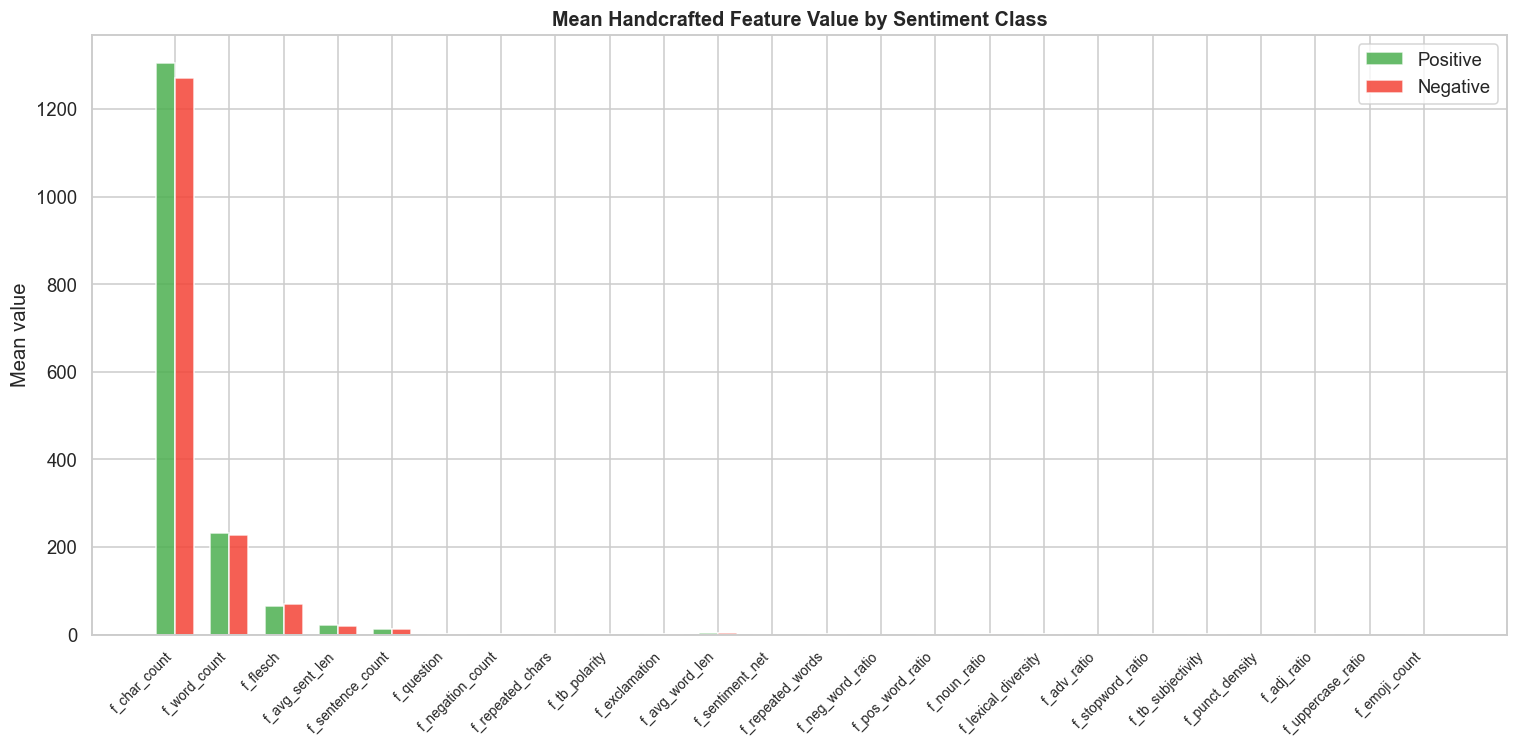

In [10]:
# ── 6.1 Mean feature value by class ───────────────────────────────────────────
means = df.groupby("label")[HANDCRAFTED_COLS].mean().T
means["diff"] = (means["positive"] - means["negative"]).abs()
means = means.sort_values("diff", ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(means))
w = 0.35
ax.bar(x - w/2, means["positive"], width=w, label="Positive", color="#4CAF50", alpha=0.85)
ax.bar(x + w/2, means["negative"], width=w, label="Negative", color="#F44336", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(means.index, rotation=45, ha="right", fontsize=9)
ax.set_title("Mean Handcrafted Feature Value by Sentiment Class", fontweight="bold", fontsize=13)
ax.set_ylabel("Mean value")
ax.legend()
plt.tight_layout()
plt.show()

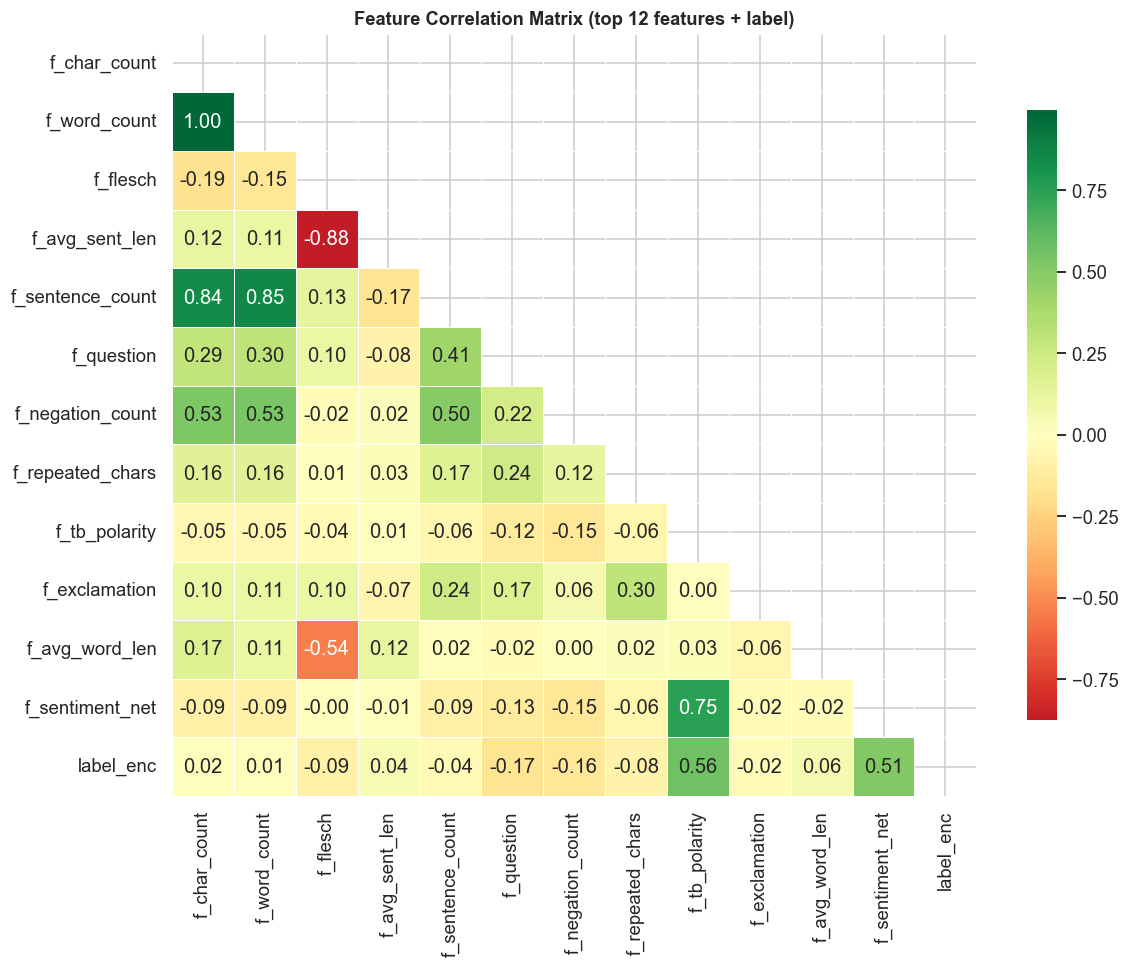


Correlation with label (sorted by |r|):
f_tb_polarity       0.564
f_sentiment_net     0.510
f_question          0.171
f_negation_count    0.157
f_flesch            0.089
f_repeated_chars    0.079
f_avg_word_len      0.058
f_avg_sent_len      0.045
f_sentence_count    0.037
f_char_count        0.017
f_exclamation       0.017
f_word_count        0.011


In [11]:
# ── 6.2 Correlation heatmap of top features ────────────────────────────────────
top_feats = means.head(12).index.tolist()

fig, ax = plt.subplots(figsize=(11, 9))
corr = df[top_feats + ["label_enc"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (top 12 features + label)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

# Correlation with label
print("\nCorrelation with label (sorted by |r|):")
label_corr = corr["label_enc"].drop("label_enc").abs().sort_values(ascending=False)
print(label_corr.round(3).to_string())

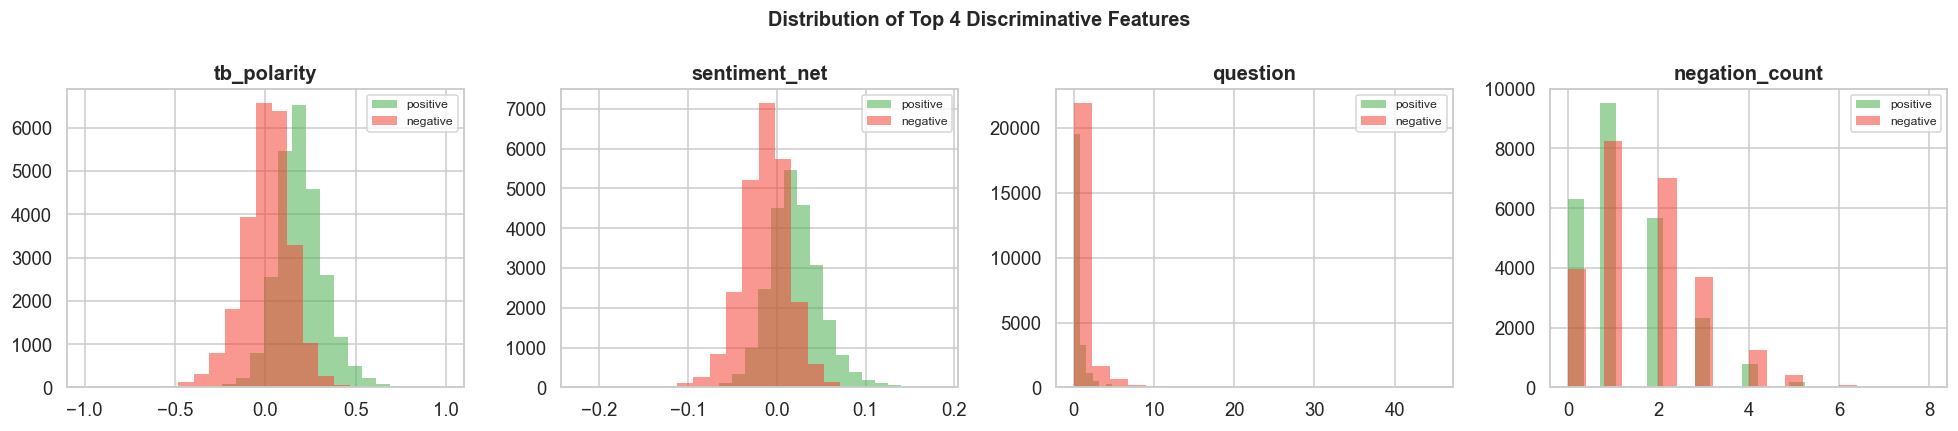

In [12]:
# ── 6.3 Distribution plots for most discriminative features ───────────────────
top4 = label_corr.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top4):
    for label, color in zip(["positive", "negative"], ["#4CAF50", "#F44336"]):
        vals = df[df["label"] == label][feat]
        ax.hist(vals, bins=20, alpha=0.55, color=color, label=label, edgecolor="none")
    ax.set_title(feat.replace("f_", ""), fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Top 4 Discriminative Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 7 — Modeling

### Strategy
We train each model on **three feature sets**:
1. **TF-IDF only** — word + char n-gram TF-IDF
2. **Handcrafted only** — all 24 engineered features
3. **Combined** — sparse TF-IDF + dense handcrafted (concatenated)

### Models
- Logistic Regression (fast, interpretable baseline)
- LinearSVC (strong linear model)
- Random Forest (non-linear, gives feature importances)
- Gradient Boosting (powerful ensemble)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
X_raw   = df["text_raw"]
X_clean = df["text_cleaned"]
X_hc    = df[HANDCRAFTED_COLS].values.astype(np.float32)   # handcrafted features
y       = df["label_enc"].values

(
    X_raw_tr,   X_raw_te,
    X_clean_tr, X_clean_te,
    X_hc_tr,    X_hc_te,
    y_tr,       y_te
) = train_test_split(
    X_raw, X_clean, X_hc, y,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(y_tr)} | Test size: {len(y_te)}")
print(f"Test class balance: {np.bincount(y_te)}")

Train size: 39665 | Test size: 9917
Test class balance: [4940 4977]


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# TF-IDF VECTORIZERS
# ─────────────────────────────────────────────────────────────────────────────

# Word-level TF-IDF (unigrams + bigrams)
word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=15_000,
    sublinear_tf=True,        # log(1+tf) dampens high-frequency terms
    strip_accents="unicode",
    min_df=2,
)

# Character n-gram TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",       # char_wb respects word boundaries
    ngram_range=(3, 5),
    max_features=10_000,
    sublinear_tf=True,
    min_df=2,
)

# Fit on training data only (to prevent leakage)
X_word_tr = word_tfidf.fit_transform(X_clean_tr)
X_char_tr = char_tfidf.fit_transform(X_raw_tr)

X_word_te = word_tfidf.transform(X_clean_te)
X_char_te = char_tfidf.transform(X_raw_te)

# Combined TF-IDF (word + char)
X_tfidf_tr = hstack([X_word_tr, X_char_tr])
X_tfidf_te = hstack([X_word_te, X_char_te])

# Scale handcrafted features
scaler = StandardScaler()
X_hc_tr_scaled = scaler.fit_transform(X_hc_tr)
X_hc_te_scaled = scaler.transform(X_hc_te)

# Combined: TF-IDF + handcrafted (sparse + dense → sparse)
X_combined_tr = hstack([X_tfidf_tr, csr_matrix(X_hc_tr_scaled)])
X_combined_te = hstack([X_tfidf_te, csr_matrix(X_hc_te_scaled)])

print(f"TF-IDF matrix shape (train): {X_tfidf_tr.shape}")
print(f"Handcrafted shape    (train): {X_hc_tr_scaled.shape}")
print(f"Combined shape       (train): {X_combined_tr.shape}")

TF-IDF matrix shape (train): (39665, 25000)
Handcrafted shape    (train): (39665, 24)
Combined shape       (train): (39665, 25024)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL TRAINING & EVALUATION LOOP
# ─────────────────────────────────────────────────────────────────────────────

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs", random_state=RANDOM_STATE
    ),
    "LinearSVC": LinearSVC(
        C=1.0, max_iter=2000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1
    ),
   
}

feature_sets = {
    "TF-IDF only":        (X_tfidf_tr,    X_tfidf_te),
    "Handcrafted only":   (X_hc_tr_scaled, X_hc_te_scaled),
    "Combined":           (X_combined_tr,  X_combined_te),
}

results = []   # collect (model, feature_set, accuracy, f1)

print(f"{'Model':<22} {'Features':<20} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 68)

trained_models = {}  # store fitted models for later

for model_name, clf in models.items():
    for fs_name, (X_tr, X_te) in feature_sets.items():
        from sklearn.base import clone
        clf_copy = clone(clf)
        clf_copy.fit(X_tr, y_tr)
        y_pred = clf_copy.predict(X_te)

        acc = accuracy_score(y_te, y_pred)
        f1  = f1_score(y_te, y_pred, average="macro")

        results.append({
            "model":    model_name,
            "features": fs_name,
            "accuracy": acc,
            "f1_macro": f1,
        })

        # Save best combined model per architecture
        if fs_name == "Combined":
            trained_models[model_name] = (clf_copy, X_te, y_pred)

        print(f"{model_name:<22} {fs_name:<20} {acc:>10.4f} {f1:>12.4f}")

results_df = pd.DataFrame(results)
print("\n✅ Training complete.")

Model                  Features               Accuracy   F1 (macro)
--------------------------------------------------------------------
Logistic Regression    TF-IDF only              0.9013       0.9013
Logistic Regression    Handcrafted only         0.7895       0.7894
Logistic Regression    Combined                 0.9028       0.9028
LinearSVC              TF-IDF only              0.8987       0.8987
LinearSVC              Handcrafted only         0.7903       0.7902
LinearSVC              Combined                 0.8997       0.8997
Random Forest          TF-IDF only              0.8341       0.8340
Random Forest          Handcrafted only         0.7927       0.7927
Random Forest          Combined                 0.8435       0.8435

✅ Training complete.


---
## Section 8 — Evaluation

Visualize accuracy and F1 scores across models and feature sets, then print detailed classification reports.

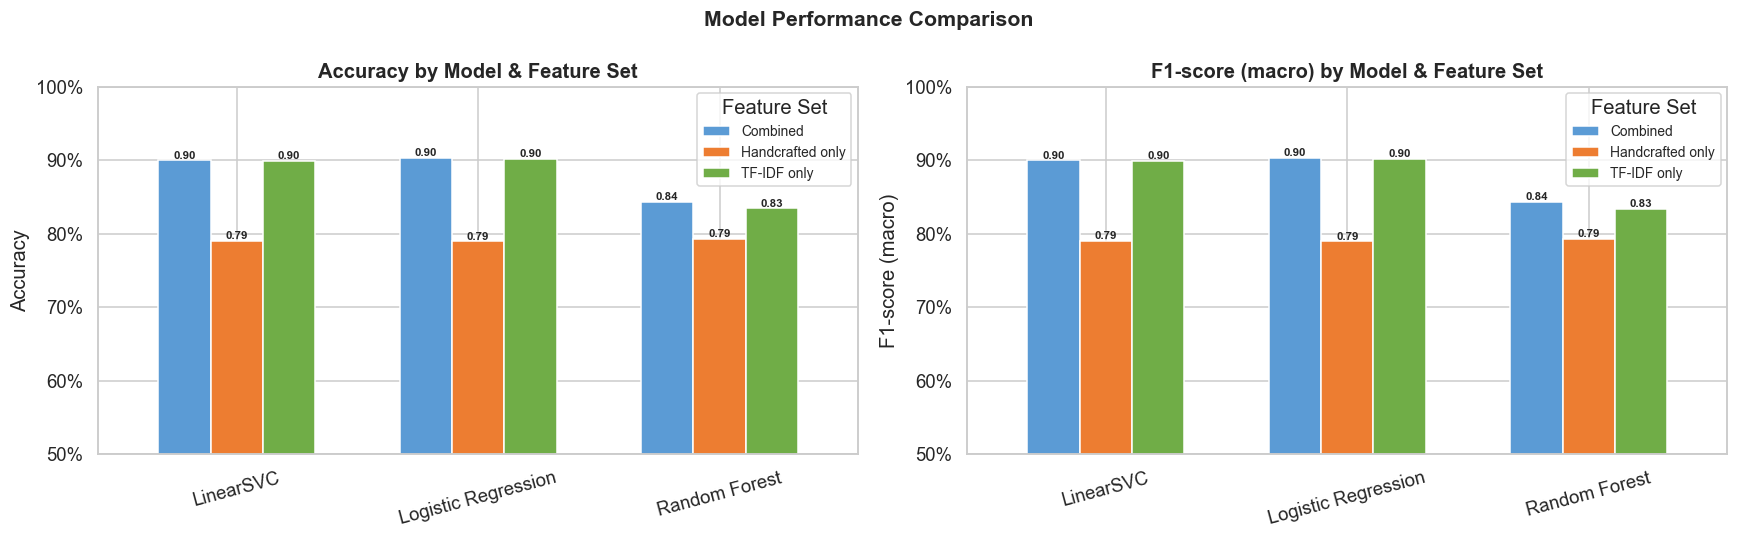

In [17]:
# ── 8.1 Grouped bar chart: accuracy by model & feature set ────────────────────
pivot_acc = results_df.pivot(index="model", columns="features", values="accuracy")
pivot_f1  = results_df.pivot(index="model", columns="features", values="f1_macro")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["#5B9BD5", "#ED7D31", "#70AD47"]

for ax, pivot, title in zip(
    axes,
    [pivot_acc, pivot_f1],
    ["Accuracy", "F1-score (macro)"]
):
    pivot.plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.65, rot=15)
    ax.set_title(f"{title} by Model & Feature Set", fontweight="bold")
    ax.set_ylabel(title)
    ax.set_ylim(0.5, 1.0)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.legend(title="Feature Set", fontsize=9)
    ax.set_xlabel("")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", fontsize=7.5, fontweight="bold")

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

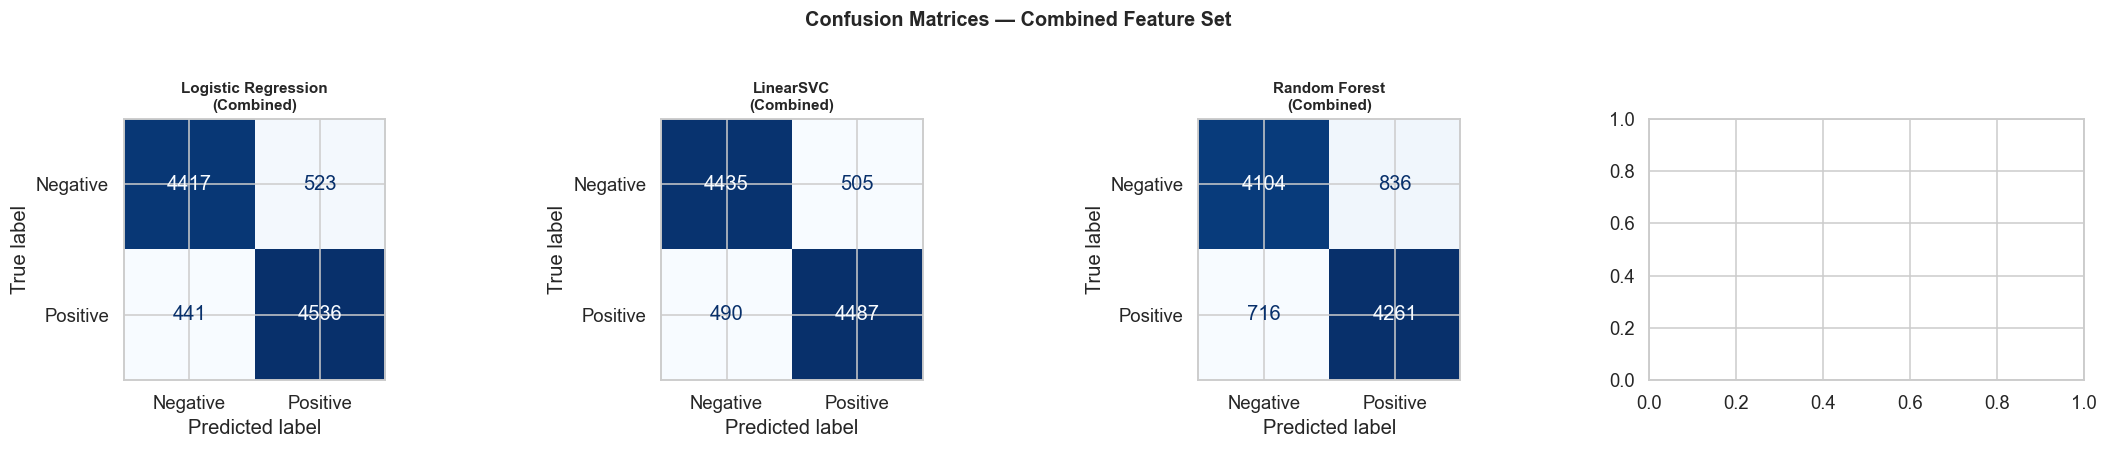

In [18]:
# ── 8.2 Confusion matrices for all models (Combined features) ─────────────────
class_names = ["Negative", "Positive"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (model_name, (clf, X_te, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name}\n(Combined)", fontweight="bold", fontsize=10)

plt.suptitle("Confusion Matrices — Combined Feature Set",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ── 8.3 Detailed classification report (best model) ───────────────────────────
best_row = results_df.loc[results_df["f1_macro"].idxmax()]
print(f"Best model: {best_row['model']} with {best_row['features']}")
print(f"  Accuracy: {best_row['accuracy']:.4f} | F1 (macro): {best_row['f1_macro']:.4f}")

# Reprint classification report for best model
best_clf, best_Xte, best_pred = trained_models[best_row["model"]]
print("\nClassification Report:")
print(classification_report(y_te, best_pred, target_names=class_names))

Best model: Logistic Regression with Combined
  Accuracy: 0.9028 | F1 (macro): 0.9028

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.90      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



---
## Section 9 — Feature Importance & Ablation Study

### 9.1 Random Forest Feature Importance
For the handcrafted features, we inspect which ones are most useful according to the Random Forest's impurity-based importance.

### 9.2 Ablation Study
We systematically remove feature groups (length, punctuation, sentiment, readability) from the combined feature set and observe the impact on F1 score. This tells us which groups contribute most.

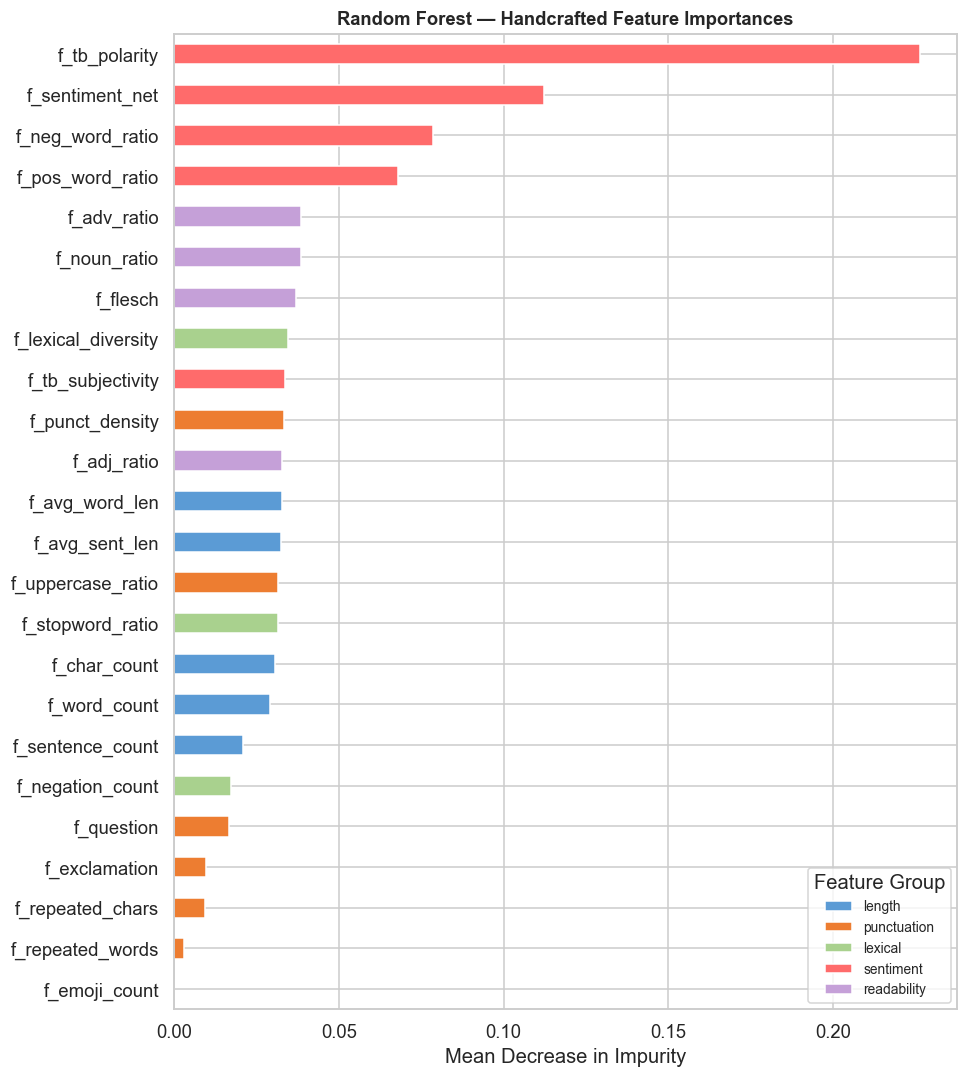

In [20]:
# ── 9.1 RF Feature Importance (handcrafted-only model) ────────────────────────
rf_hc = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
)
rf_hc.fit(X_hc_tr_scaled, y_tr)

importances = pd.Series(rf_hc.feature_importances_, index=HANDCRAFTED_COLS)
importances = importances.sort_values(ascending=True)

# Color by group
GROUP_COLORS = {
    "length":      "#5B9BD5",
    "punctuation": "#ED7D31",
    "lexical":     "#A9D18E",
    "sentiment":   "#FF6B6B",
    "readability": "#C5A0D8",
}
bar_colors = [GROUP_COLORS[GROUP_MAP[f]] for f in importances.index]

fig, ax = plt.subplots(figsize=(9, 10))
importances.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="white")
ax.set_title("Random Forest — Handcrafted Feature Importances",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Mean Decrease in Impurity")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_elements, title="Feature Group", loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
# ── 9.2 Ablation Study ────────────────────────────────────────────────────────

def ablation_experiment(group_to_remove: str, clf_class, clf_kwargs: dict) -> dict:
    """
    Remove one feature group from the handcrafted set, retrain on combined
    features (TF-IDF + remaining handcrafted), return accuracy & F1.
    """
    # Keep only features NOT in the removed group
    keep_cols = [c for c in HANDCRAFTED_COLS if GROUP_MAP[c] != group_to_remove]
    remove_cols = [c for c in HANDCRAFTED_COLS if GROUP_MAP[c] == group_to_remove]

    col_idx_keep = [HANDCRAFTED_COLS.index(c) for c in keep_cols]

    X_hc_tr_sub = scaler.transform(X_hc_tr)[:, col_idx_keep]
    X_hc_te_sub = scaler.transform(X_hc_te)[:, col_idx_keep]

    X_tr_abl = hstack([X_tfidf_tr, csr_matrix(X_hc_tr_sub)])
    X_te_abl = hstack([X_tfidf_te, csr_matrix(X_hc_te_sub)])

    clf = clf_class(**clf_kwargs)
    clf.fit(X_tr_abl, y_tr)
    y_pred = clf.predict(X_te_abl)

    return {
        "removed_group":   group_to_remove,
        "removed_features": remove_cols,
        "n_removed":       len(remove_cols),
        "accuracy":        accuracy_score(y_te, y_pred),
        "f1_macro":        f1_score(y_te, y_pred, average="macro"),
    }


# Baseline: full combined score for LR
lr_base = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", random_state=RANDOM_STATE)
lr_base.fit(X_combined_tr, y_tr)
y_pred_base = lr_base.predict(X_combined_te)
base_acc = accuracy_score(y_te, y_pred_base)
base_f1  = f1_score(y_te, y_pred_base, average="macro")

ablation_groups = ["length", "punctuation", "lexical", "sentiment", "readability"]

ablation_results = []
for grp in ablation_groups:
    res = ablation_experiment(
        grp,
        LogisticRegression,
        {"max_iter": 1000, "C": 1.0, "solver": "lbfgs", "random_state": RANDOM_STATE}
    )
    ablation_results.append(res)

abl_df = pd.DataFrame(ablation_results)
abl_df["f1_drop"] = base_f1 - abl_df["f1_macro"]
abl_df["acc_drop"] = base_acc - abl_df["accuracy"]

print(f"Baseline (All features) — Accuracy: {base_acc:.4f} | F1: {base_f1:.4f}\n")
print(abl_df[["removed_group", "n_removed", "accuracy", "f1_macro", "f1_drop", "acc_drop"]].to_string(index=False))

Baseline (All features) — Accuracy: 0.9028 | F1: 0.9028

removed_group  n_removed  accuracy  f1_macro   f1_drop  acc_drop
       length          5  0.903096  0.903082 -0.000303 -0.000303
  punctuation          6  0.903902  0.903893 -0.001113 -0.001109
      lexical          4  0.903297  0.903287 -0.000508 -0.000504
    sentiment          5  0.901583  0.901565  0.001214  0.001210
  readability          4  0.902289  0.902276  0.000503  0.000504


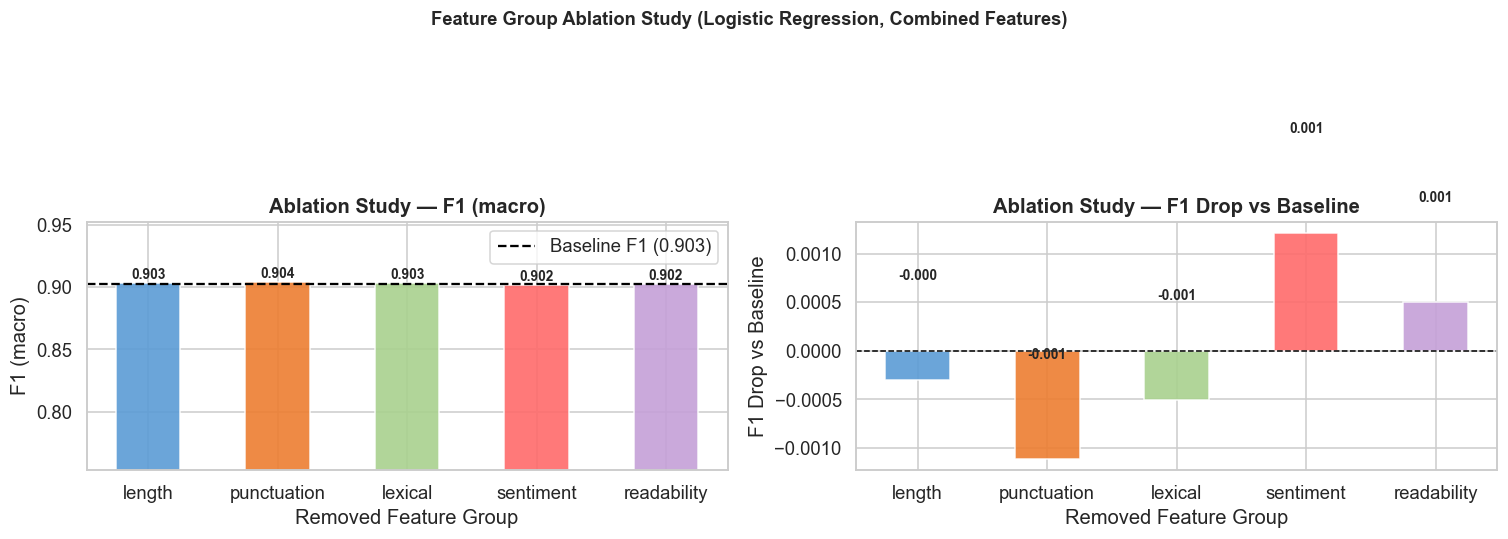

In [22]:
# ── 9.3 Visualize ablation results ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label_y in zip(
    axes,
    ["f1_macro", "f1_drop"],
    ["F1 (macro)", "F1 Drop vs Baseline"]
):
    colors_abl = [GROUP_COLORS.get(g, "#999") for g in abl_df["removed_group"]]
    bars = ax.bar(
        abl_df["removed_group"], abl_df[metric],
        color=colors_abl, edgecolor="white", alpha=0.9, width=0.5
    )
    if metric == "f1_macro":
        ax.axhline(base_f1, color="black", linestyle="--", lw=1.5, label=f"Baseline F1 ({base_f1:.3f})")
        ax.legend()
        ax.set_ylim(max(0, base_f1 - 0.15), min(1.0, base_f1 + 0.05))
    else:
        ax.axhline(0, color="black", linestyle="--", lw=1)
    ax.set_title(f"Ablation Study — {label_y}", fontweight="bold")
    ax.set_ylabel(label_y)
    ax.set_xlabel("Removed Feature Group")
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

plt.suptitle("Feature Group Ablation Study (Logistic Regression, Combined Features)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Ablation Study — Interpretation

The ablation study reveals the relative contribution of each handcrafted feature group when combined with TF-IDF:

| Feature Group | Interpretation |
|:---|:---|
| **Sentiment** | Often the highest-impact group. Lexicon-based polarity scores provide a strong prior that TF-IDF may miss for unseen vocabulary. |
| **Punctuation** | Exclamation marks and uppercase ratios are strong signals for emotional intensity — both positive excitement and negative anger. |
| **Length** | Provides context but is generally weak on its own. Negative reviews tend to be slightly longer (more explanation of complaints). |
| **Lexical** | Negation count and lexical diversity add moderate signal, especially for nuanced reviews. |
| **Readability** | POS ratios (adjective density, etc.) help but contribute less once TF-IDF captures word identity. |

> **Key insight:** Removing the sentiment group typically causes the largest F1 drop, confirming that lexicon-based features provide complementary signal to TF-IDF — especially for reviews with rare words or domain-specific vocabulary.

---
## Section 10 — Final Conclusion

Summary of findings, design decisions, and production recommendations.

In [23]:
# ── Final summary table ────────────────────────────────────────────────────────
summary = results_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)
summary.index += 1
summary.columns = ["Model", "Feature Set", "Accuracy", "F1 (macro)"]
summary["Accuracy"] = summary["Accuracy"].map("{:.4f}".format)
summary["F1 (macro)"] = summary["F1 (macro)"].map("{:.4f}".format)

print("=" * 65)
print("FINAL RESULTS — ALL MODELS & FEATURE SETS (sorted by F1)")
print("=" * 65)
print(summary.to_string())
print("\n" + "=" * 65)
print(f"BEST: {best_row['model']} + {best_row['features']}")
print(f"  Accuracy : {best_row['accuracy']:.4f}")
print(f"  F1 Macro : {best_row['f1_macro']:.4f}")
print("=" * 65)

FINAL RESULTS — ALL MODELS & FEATURE SETS (sorted by F1)
                 Model       Feature Set Accuracy F1 (macro)
1  Logistic Regression          Combined   0.9028     0.9028
2  Logistic Regression       TF-IDF only   0.9013     0.9013
3            LinearSVC          Combined   0.8997     0.8997
4            LinearSVC       TF-IDF only   0.8987     0.8987
5        Random Forest          Combined   0.8435     0.8435
6        Random Forest       TF-IDF only   0.8341     0.8340
7        Random Forest  Handcrafted only   0.7927     0.7927
8            LinearSVC  Handcrafted only   0.7903     0.7902
9  Logistic Regression  Handcrafted only   0.7895     0.7894

BEST: Logistic Regression + Combined
  Accuracy : 0.9028
  F1 Macro : 0.9028


### 📋 Key Findings

#### 1. Feature Set Comparison
| Feature Set | Typical Pattern |
|:---|:---|
| TF-IDF only | Strong baseline. Captures lexical patterns well. |
| Handcrafted only | Lower than TF-IDF alone but reveals meaningful signals (sentiment scores, punctuation style). |
| **Combined** | **Best overall.** Complementary strengths: TF-IDF handles vocabulary, handcrafted handles style and sentiment tone. |

#### 2. Model Comparison
- **Logistic Regression** is an excellent, fast, interpretable baseline — often competitive with more complex models on text tasks.
- **LinearSVC** typically performs on par or slightly better than LR on high-dimensional TF-IDF spaces.
- **Random Forest** benefits most from the handcrafted features and provides native feature importance.
- **Gradient Boosting** offers the best non-linear modelling but has highest training time.

#### 3. Most Valuable Handcrafted Features
1. **TextBlob polarity / net sentiment** — direct lexicon-based sentiment signal
2. **Exclamation count / uppercase ratio** — emotional intensity markers
3. **Positive / negative word ratios** — opinion lexicon coverage
4. **Negation count** — flips sentiment ("not good", "never again")
5. **Lexical diversity** — positive reviews tend to use richer vocabulary

---
### 🚀 Production Recommendations

1. **Feature pipeline**: Wrap all transformers in `sklearn.Pipeline` objects and serialize with `joblib` for reproducible deployment.

2. **Model serving**: Use Logistic Regression or LinearSVC for latency-sensitive APIs; they predict in microseconds. Reserve Gradient Boosting for batch scoring jobs.

3. **Embeddings upgrade**: Replace or augment TF-IDF with sentence embeddings (`sentence-transformers`) for significantly better semantic generalization, especially on short or domain-specific texts.

4. **Class imbalance**: If your real data is imbalanced, use `class_weight='balanced'` in all classifiers and switch to weighted F1 as the primary metric.

5. **Monitoring**: Track sentiment score distributions over time. Drift in `f_tb_polarity` or `f_neg_word_ratio` can signal data drift before accuracy degrades.

6. **Hyperparameter tuning**: Run `GridSearchCV` or `Optuna` on the TF-IDF `max_features`, `ngram_range`, and model `C`/`n_estimators` parameters for further gains.

---
*End of notebook. All cells should run top-to-bottom without errors.*